In [66]:
from __future__ import annotations
import sys
sys.path.insert(0, "../../operon-project/code/graph_api")
sys.path.insert(0, "../../operon-project/code/search_pipeline")
sys.path.insert(0, "../")
from AMR_analysis.utils import _load_single_subgraph_pkl, load_functional_groups_file

from graph_classes import Subgraph, ReferenceGraph, MergedGraph, Edge, Node
from graph_classes import nameddict, count_fg_occurence, read_meta_data, get_graph_id, get_subgraph_id, \
    has_existing_graph_builds, delete_file, load_modified_from_pickle_if_exists, reset_subgraph_and_delete_modified
from graph_classes import ABUNDANCE_DETECTION_LIMIT, TXT_POSTFIX, JSON_POSTFIX, PICKLE_POSTFIX, MODIFIED_POSTFIX
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from matplotlib.lines import Line2D
import seaborn as sns

from __future__ import annotations

import numpy as np
import re
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.pyplot as plt
from __future__ import annotations

from pathlib import Path
import pandas as pd

In [67]:
# Load Data

In [68]:


graphs_dir = Path('../data/runs/amr_res_test/window-size_10/min-contigs_3/min-domains-matched_1/graphs/')

graph_to_subgraph = {
    gf.name: _load_single_subgraph_pkl(gf)
    for gf in sorted(graphs_dir.glob("graph_*"))
    if gf.is_dir()
}

In [69]:
gc_nodes_to_integrase_path = Path('../data/runs/filtered_integrase_gc/functional_groups.txt')
gc_node_to_integrase = load_functional_groups_file(gc_nodes_to_integrase_path)

gc_nodes_to_AMR_path = Path('../data/runs/pfam_constrained_amr/functional_groups.txt')
gc_node_to_AMR = load_functional_groups_file(gc_nodes_to_AMR_path)

In [70]:
# Create table of prevalence per gc node per graph

In [71]:
# Build rows for: graph_id | gc_id | MatchType | ElementSymbol | RawPrevalence | RelativePrevalence

rows = []

for graph_key, sg in graph_to_subgraph.items():
    # graph_id: prefer helper if it works, otherwise fall back to folder name
    try:
        graph_id = get_graph_id(sg)
    except Exception:
        graph_id = graph_key

    gc_id_to_node = getattr(sg, "gc_id_to_node", None)
    if gc_id_to_node is None:
        raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

    for gc_id, node in gc_id_to_node.items():
        matches = []
        if gc_id in gc_node_to_AMR:
            matches.append(("AMR", gc_node_to_AMR[gc_id]))
        if gc_id in gc_node_to_integrase:
            matches.append(("Integrase", gc_node_to_integrase[gc_id]))

        if not matches:
            continue

        abundance_annotation = getattr(node, "abundance_annotation", None)
        if abundance_annotation is None:
            raise AttributeError(f"Node for gc_id={gc_id} in graph={graph_id} has no 'abundance_annotation'")

        total_samples = len(abundance_annotation)
        raw_prevalence = 0
        for v in abundance_annotation.values():
            try:
                raw_prevalence += 1 if float(v) > 0 else 0
            except Exception:
                # If values are non-numeric, treat as not present
                raw_prevalence += 0

        relative_prevalence = (raw_prevalence / total_samples) if total_samples else 0.0

        for match_type, element_symbol in matches:
            if isinstance(element_symbol, (list, tuple, set)):
                element_symbol = ";".join(map(str, element_symbol))

            rows.append({
                "graph_id": graph_id,
                "gc_id": gc_id,
                "MatchType": match_type,
                "ElementSymbol": element_symbol,
                "RawPrevalence": raw_prevalence,
                "RelativePrevalence": relative_prevalence,
            })


In [72]:
# Build DataFrame
gc_match_prevalence_df = pd.DataFrame(rows)

gc_match_prevalence_df["graph_id"] = (
    gc_match_prevalence_df["graph_id"].astype(str)
    .str.replace(r"^(graph_)(\d)$", r"\g<1>0\g<2>", regex=True)
    .astype("category")
)

# Make appropriate columns categorical to save memory
categorical_cols = [
    "graph_id",
    "gc_id",
    "MatchType",
    "ElementSymbol",
]

for col in categorical_cols:
    if col in gc_match_prevalence_df.columns:
        gc_match_prevalence_df[col] = gc_match_prevalence_df[col].astype("category")

In [73]:
# Group by graph and get the mean amr relative and mean integrase relative prevalance
gc_match_prevalence_summary_df = gc_match_prevalence_df.groupby(
    ["graph_id", "MatchType"]
).agg(
    MeanRelativePrevalence=("RelativePrevalence", "mean"),
    MeanRawPrevalence=("RawPrevalence", "mean"),
    CountMatches=("gc_id", "nunique")
).reset_index()

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/742246081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gc_match_prevalence_summary_df = gc_match_prevalence_df.groupby(


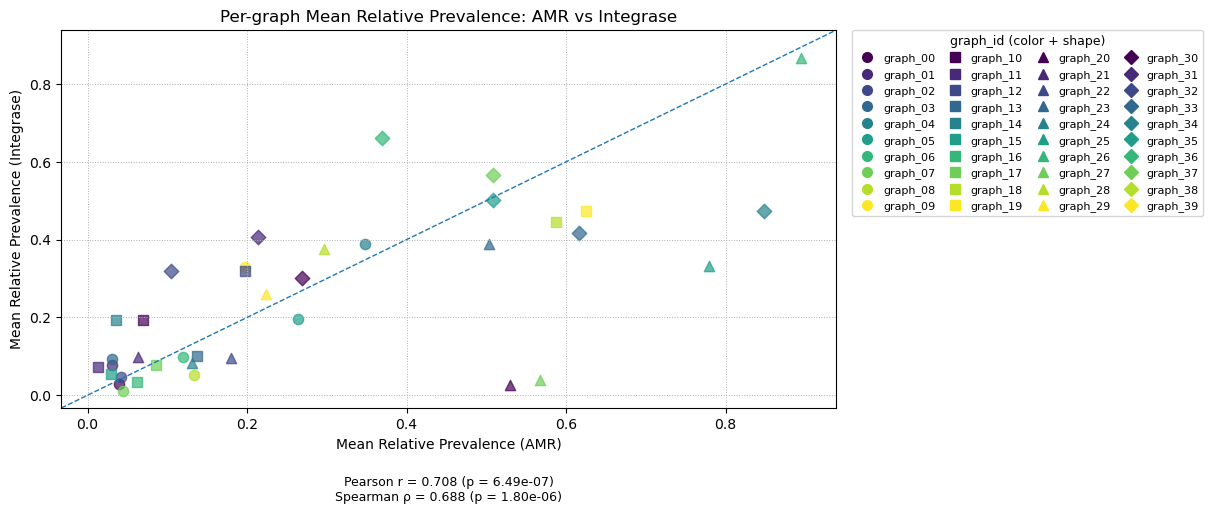

In [74]:
# Build per-graph wide table (AMR vs Integrase)
graph_mean_relative_prevalence_wide_df = (
    gc_match_prevalence_summary_df
    .pivot(index="graph_id", columns="MatchType", values="MeanRelativePrevalence")
    .rename(columns={"AMR": "MeanRelativePrevalence_AMR", "Integrase": "MeanRelativePrevalence_Integrase"})
    .reset_index()
    .dropna(subset=["MeanRelativePrevalence_AMR", "MeanRelativePrevalence_Integrase"])
)

# Parse numeric id for grouping (00-09, 10-19, 20-29, 30-39)
graph_mean_relative_prevalence_wide_df["graph_num"] = (
    graph_mean_relative_prevalence_wide_df["graph_id"].astype(str).str.extract(r"(\d+)$")[0].astype(int)
)
graph_mean_relative_prevalence_wide_df = graph_mean_relative_prevalence_wide_df.sort_values("graph_num")

# 10-step ordered palette reused per decade + marker encodes decade
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 0-9, 10-19, 20-29, 30-39

# Plot points (no auto-legend labels)
fig, ax = plt.subplots(figsize=(10, 6))

base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

for _, row in graph_mean_relative_prevalence_wide_df.iterrows():
    graph_num = int(row["graph_num"])
    decade = graph_num // 10
    within_decade = graph_num % 10

    ax.scatter(
        row["MeanRelativePrevalence_AMR"],
        row["MeanRelativePrevalence_Integrase"],
        s=55,
        alpha=0.7,
        marker=decade_to_marker.get(decade, "o"),
        color=ten_step_colors[within_decade],
    )

# y = x line
x_vals = graph_mean_relative_prevalence_wide_df["MeanRelativePrevalence_AMR"].to_numpy()
y_vals = graph_mean_relative_prevalence_wide_df["MeanRelativePrevalence_Integrase"].to_numpy()
pearson_r, pearson_p = pearsonr(x_vals, y_vals)
spearman_r, spearman_p = spearmanr(x_vals, y_vals)

correlation_text = (
    f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})"
)
ax.text(
    0.5, -0.18,
    correlation_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=9,
)
min_val = float(min(x_vals.min(), y_vals.min()))
max_val = float(max(x_vals.max(), y_vals.max()))
pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.05
line_min, line_max = (min_val - pad), (max_val + pad)
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=1)

ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)
ax.set_xlabel("Mean Relative Prevalence (AMR)")
ax.set_ylabel("Mean Relative Prevalence (Integrase)")
ax.set_title("Per-graph Mean Relative Prevalence: AMR vs Integrase")
ax.grid(True, linestyle=":", linewidth=0.7)

# Legend that explicitly lists each graph_id with its marker + color
from matplotlib.lines import Line2D

graph_style_legend_handles = []
graph_style_legend_labels = []

for graph_num in range(40):
    graph_id = f"graph_{graph_num:02d}"
    decade = graph_num // 10
    within_decade = graph_num % 10

    graph_style_legend_handles.append(
        Line2D(
            [0], [0],
            marker=decade_to_marker.get(decade, "o"),
            linestyle="None",
            markerfacecolor=ten_step_colors[within_decade],
            markeredgecolor=ten_step_colors[within_decade],
            markersize=7,
        )
    )
    graph_style_legend_labels.append(graph_id)

ax.legend(
    handles=graph_style_legend_handles,
    labels=graph_style_legend_labels,
    title="graph_id (color + shape)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=4,
    fontsize=8,
    title_fontsize=9,
    handletextpad=0.4,
    columnspacing=0.8,
)

fig.subplots_adjust(bottom=0.25)  # makes room for the correlation text under the axis labels
plt.show()



In [75]:
# Build a per-sample table:
# graph_id | sample_id | MeanAbundance_AMR | MeanAbundance_Integrase

rows = []

for graph_key, sg in graph_to_subgraph.items():
    try:
        graph_id = get_graph_id(sg)
    except Exception:
        graph_id = graph_key

    gc_id_to_node = getattr(sg, "gc_id_to_node", None)
    if gc_id_to_node is None:
        raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

    amr_gc_ids = [gc_id for gc_id in gc_id_to_node.keys() if gc_id in gc_node_to_AMR]
    int_gc_ids = [gc_id for gc_id in gc_id_to_node.keys() if gc_id in gc_node_to_integrase]

    # keep only graphs where both exist (since you want AMR vs Integrase)
    if not amr_gc_ids or not int_gc_ids:
        continue

    # union of sample ids across the involved nodes (robust to missing keys)
    sample_ids = set()
    for gc_id in amr_gc_ids + int_gc_ids:
        ann = getattr(gc_id_to_node[gc_id], "abundance_annotation", None)
        if ann is None:
            raise AttributeError(f"Node for gc_id={gc_id} in graph={graph_id} has no 'abundance_annotation'")
        sample_ids.update(ann.keys())

    for sample_id in sample_ids:
        amr_vals = []
        for gc_id in amr_gc_ids:
            v = gc_id_to_node[gc_id].abundance_annotation.get(sample_id, 0)
            try:
                amr_vals.append(float(v))
            except Exception:
                amr_vals.append(0.0)

        int_vals = []
        for gc_id in int_gc_ids:
            v = gc_id_to_node[gc_id].abundance_annotation.get(sample_id, 0)
            try:
                int_vals.append(float(v))
            except Exception:
                int_vals.append(0.0)

        rows.append(
            {
                "graph_id": str(graph_id),
                "sample_id": str(sample_id),
                "MeanAbundance_AMR": float(np.mean(amr_vals)) if amr_vals else np.nan,
                "MeanAbundance_Integrase": float(np.mean(int_vals)) if int_vals else np.nan,
            }
        )

sample_abundance_df = pd.DataFrame(rows).dropna(subset=["MeanAbundance_AMR", "MeanAbundance_Integrase"])

# graph_num for styling (expects suffix digits like graph_00 ... graph_39)
sample_abundance_df["graph_num"] = (
    sample_abundance_df["graph_id"].str.extract(r"(\d+)$")[0].astype(int)
)
sample_abundance_df = sample_abundance_df.sort_values(["graph_num", "sample_id"])

# style maps (same as your previous scheme)
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

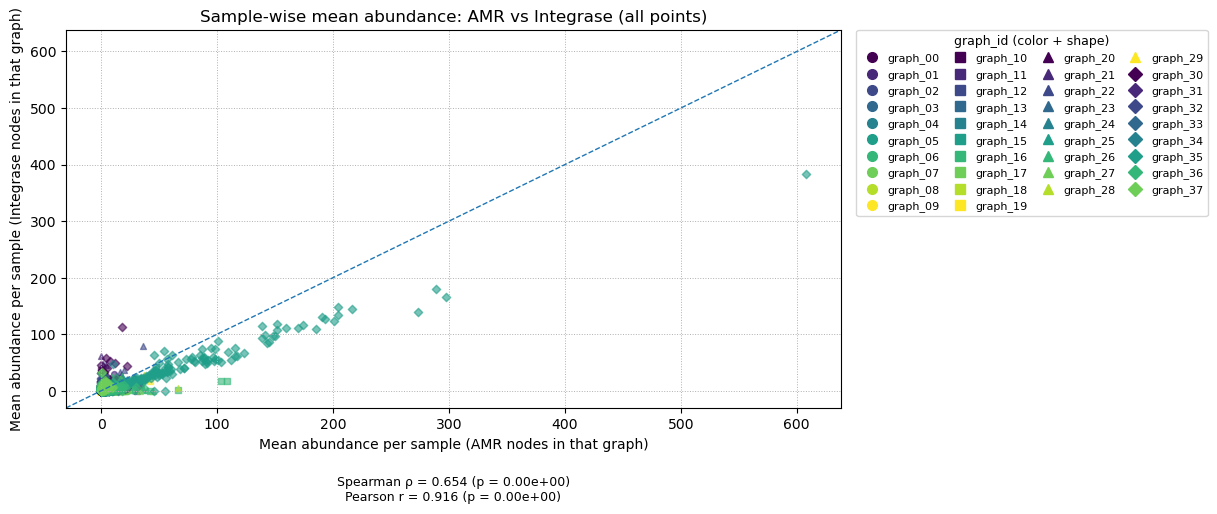

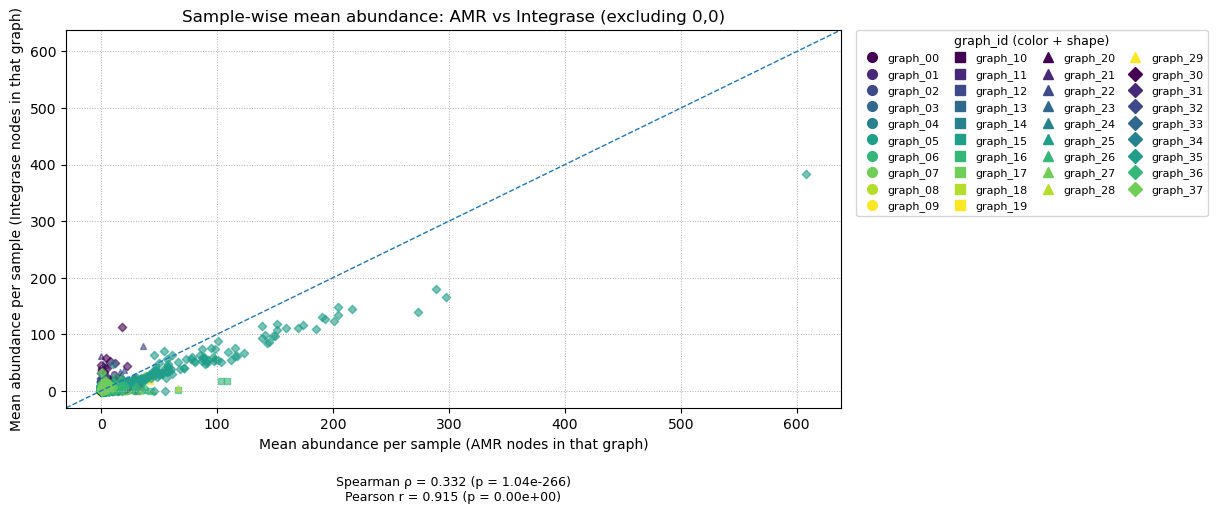

In [76]:
def plot_sample_scatter_fast(df: pd.DataFrame, drop_zero_zero: bool, title: str) -> None:
    if drop_zero_zero:
        d = df.loc[~((df["MeanAbundance_AMR"] == 0) & (df["MeanAbundance_Integrase"] == 0))].copy()
    else:
        d = df.copy()

    # correlations (can be the slow part if you have huge N)
    x = d["MeanAbundance_AMR"].to_numpy(dtype=float)
    y = d["MeanAbundance_Integrase"].to_numpy(dtype=float)

    spearman_r, spearman_p = spearmanr(x, y)
    pearson_r, pearson_p = pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(10, 6))

    # scatter in <= 40 calls (one per graph_num)
    for gnum, g in d.groupby("graph_num", sort=True):
        gnum = int(gnum)
        decade = gnum // 10
        within = gnum % 10
        ax.scatter(
            g["MeanAbundance_AMR"].to_numpy(),
            g["MeanAbundance_Integrase"].to_numpy(),
            s=18,
            alpha=0.6,
            marker=decade_to_marker.get(decade, "o"),
            color=ten_step_colors[within],
            rasterized=True,  # big speed-up for large point clouds (esp. when saving)
        )

    # y = x line (based on visible points)
    if len(x) > 0:
        min_val = float(min(x.min(), y.min()))
        max_val = float(max(x.max(), y.max()))
        pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.05
        line_min, line_max = (min_val - pad), (max_val + pad)
        ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=1)
        ax.set_xlim(line_min, line_max)
        ax.set_ylim(line_min, line_max)

    ax.set_xlabel("Mean abundance per sample (AMR nodes in that graph)")
    ax.set_ylabel("Mean abundance per sample (Integrase nodes in that graph)")
    ax.set_title(title)
    ax.grid(True, linestyle=":", linewidth=0.7)

    corr_text = (
        f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\n"
        f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})"
    )
    ax.text(0.5, -0.18, corr_text, transform=ax.transAxes, ha="center", va="top", fontsize=9)

    # legend: only graphs present
    present_graph_nums = sorted(d["graph_num"].unique().tolist())
    handles, labels = [], []
    for gnum in present_graph_nums:
        decade = gnum // 10
        within = gnum % 10
        handles.append(
            Line2D(
                [0], [0],
                marker=decade_to_marker.get(decade, "o"),
                linestyle="None",
                markerfacecolor=ten_step_colors[within],
                markeredgecolor=ten_step_colors[within],
                markersize=7,
            )
        )
        labels.append(f"graph_{gnum:02d}")
    ax.legend(
        handles=handles,
        labels=labels,
        title="graph_id (color + shape)",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncol=4,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    fig.subplots_adjust(bottom=0.25)
    plt.show()
plot_sample_scatter_fast(
    sample_abundance_df,
    drop_zero_zero=False,
    title="Sample-wise mean abundance: AMR vs Integrase (all points)",
)

plot_sample_scatter_fast(
    sample_abundance_df,
    drop_zero_zero=True,
    title="Sample-wise mean abundance: AMR vs Integrase (excluding 0,0)",
)

In [77]:
# Calculate the spearman correlations for each graph individually, so basically I would want a table with graph_id | spearman_r | spearman_p
# graph_id | spearman_r | spearman_p (computed within each graph)
spearman_by_graph_df = (
    sample_abundance_df
    .groupby("graph_id", sort=True)
    .apply(lambda g: pd.Series(
        spearmanr(g["MeanAbundance_AMR"].to_numpy(dtype=float),
                  g["MeanAbundance_Integrase"].to_numpy(dtype=float)),
        index=["spearman_r", "spearman_p"],
    ))
    .reset_index()
)
spearman_by_graph_df['log10_spearman_p'] = -np.log10(spearman_by_graph_df['spearman_p'].replace(0, np.nextafter(0, 1)))

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/1834018873.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(


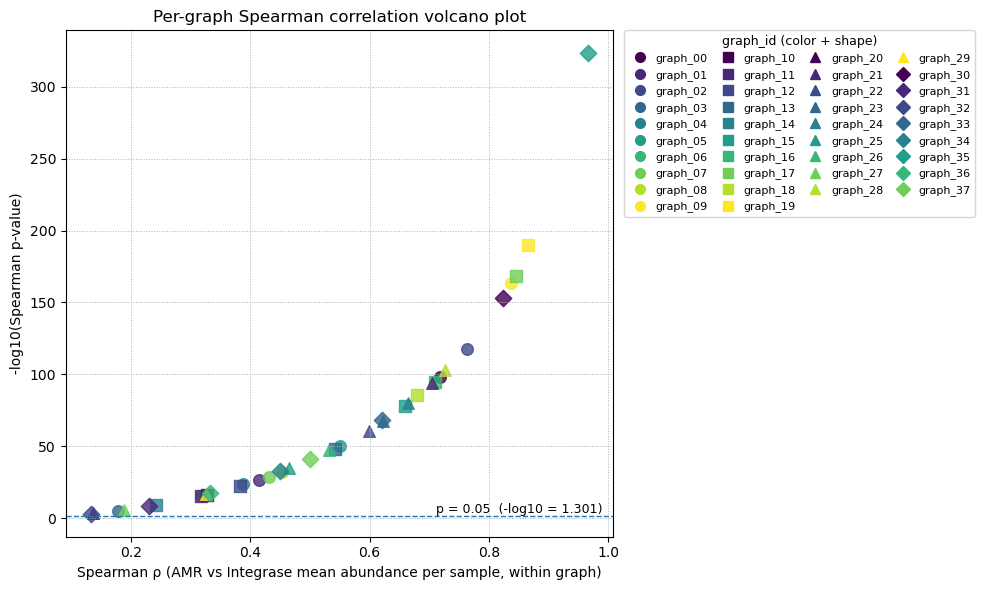

In [78]:
# Ensure graph_num exists (for decade marker + within-decade color)
spearman_by_graph_df["graph_num"] = (
        spearman_by_graph_df["graph_id"].astype(str).str.extract(r"(\d+)$")[0].astype(int)
    )

# Same styling scheme as before
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

# Volcano plot: x = Spearman rho, y = -log10(p)
d = spearman_by_graph_df.dropna(subset=["spearman_r", "log10_spearman_p", "graph_num"]).copy()
d = d.sort_values("graph_num")

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in d.iterrows():
    gnum = int(row["graph_num"])
    decade = gnum // 10
    within = gnum % 10
    ax.scatter(
        row["spearman_r"],
        row["log10_spearman_p"],
        s=70,
        alpha=0.8,
        marker=decade_to_marker.get(decade, "o"),
        color=ten_step_colors[within],
    )

# Significance threshold line at p=0.05
sig_y = -np.log10(0.05)
ax.axhline(sig_y, linestyle="--", linewidth=1)
ax.text(
    0.98, sig_y,
    f"p = 0.05  (-log10 = {sig_y:.3f})",
    ha="right", va="bottom",
    transform=ax.get_yaxis_transform(),
    fontsize=9,
)

ax.set_xlabel("Spearman ρ (AMR vs Integrase mean abundance per sample, within graph)")
ax.set_ylabel("-log10(Spearman p-value)")
ax.set_title("Per-graph Spearman correlation volcano plot")
ax.grid(True, linestyle=":", linewidth=0.7)

# Legend: one entry per graph_id (color + shape)
handles, labels = [], []
for gnum in d["graph_num"].astype(int).tolist():
    decade = gnum // 10
    within = gnum % 10
    handles.append(
        Line2D(
            [0], [0],
            marker=decade_to_marker.get(decade, "o"),
            linestyle="None",
            markerfacecolor=ten_step_colors[within],
            markeredgecolor=ten_step_colors[within],
            markersize=7,
        )
    )
    labels.append(f"graph_{gnum:02d}")

ax.legend(
    handles=handles,
    labels=labels,
    title="graph_id (color + shape)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=4,
    fontsize=8,
    title_fontsize=9,
    handletextpad=0.4,
    columnspacing=0.8,
)

plt.tight_layout()
plt.show()

In [79]:
spearman_by_graph_df

,graph_id,spearman_r,spearman_p,log10_spearman_p,graph_num
0,graph_0,0.718536,6.565295e-99,98.182746,0
1,graph_1,0.414564,4.170220e-27,26.379841,1
2,graph_10,0.327801,4.517132e-17,16.345137,10
3,graph_11,0.317657,5.590909e-16,15.252518,11
4,graph_12,0.382608,2.518606e-23,22.598840,12
5,graph_13,0.541104,6.725420e-49,48.172281,13
6,graph_14,0.241496,1.051969e-09,8.977997,14
7,graph_15,0.660142,2.399865e-78,77.619813,15
8,graph_16,0.709006,4.710797e-95,94.326906,16
9,graph_17,0.845168,6.504540e-169,168.186783,17


In [80]:

def _as_str(x) -> str:
    if x is None:
        return None
    if isinstance(x, (list, tuple, set)):
        return ";".join(map(str, x))
    return str(x)

def _clean_or_na(x, na="Not Annotated") -> str:
    if x is None:
        return na
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return na
    return s
def pick_tax_field(node, candidate_keys, default="unannotated") -> str:
    tax = getattr(node, "taxonomy", None) or {}
    for k in candidate_keys:
        if k in tax and tax[k] not in (None, "", "nan", "NaN"):
            return _as_str(tax[k])
    return default

# Candidate keys: adjust as you discover the actual keys in node.taxonomy
TAXPHLAN_KEYS = ["taxphlan", "taxaplan", "taxa_plan", "metaphlan", "MetaPhlAn", "metaphlan_taxonomy", "metaphlan_ann"]
GDK_KEYS      = ["gdk", "gtdbtk_ann", "gtdbtk", "GTDB-Tk", "gtdb"]
MSP_KEYS      = ["msp", "MSP", "msp_id", "msp_taxonomy"]
def pick_tax(node, keys, na="Not Annotated") -> str:
    tax = getattr(node, "taxonomy", None) or {}
    for k in keys:
        if k in tax:
            v = tax.get(k)
            v = _as_str(v)
            if v is not None and str(v).strip() != "":
                return _clean_or_na(v, na=na)
    return na
def _wrap(s: str, width: int) -> str:
    s = "" if s is None else str(s)
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False, replace_whitespace=False)) or s


# Anaylsis of integrase node taxa

In [81]:
# 0) Add gene_category to your integrase_tax_df (recommended: rebuild once)
# If you want to keep your existing df, skip this and see the note below.
#
# In your integrase_tax_df construction loop, add:
#   "gene_category": pick_tax(node, ["gene_category"], na="Not Annotated")

# Example quick rebuild (only the rows part shown):
rows = []
for graph_key, sg in graph_to_subgraph.items():
    try:
        graph_id = str(get_graph_id(sg))
    except Exception:
        graph_id = str(graph_key)

    gc_id_to_node = getattr(sg, "gc_id_to_node", None)
    if gc_id_to_node is None:
        raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

    integrase_gc_ids = set(gc_id_to_node.keys()).intersection(gc_node_to_integrase.keys())

    for gc_id in sorted(integrase_gc_ids):
        node = gc_id_to_node[gc_id]
        integrase_name = gc_node_to_integrase[gc_id]
        integrase_name = ";".join(map(str, integrase_name)) if isinstance(integrase_name, (list, tuple, set)) else str(integrase_name)

        rows.append({
            "Graph": graph_id,
            "gc_id": str(gc_id),
            "IntegraseName": integrase_name,
            "metaphlan_ann": pick_tax(node, TAXPHLAN_KEYS, na="Not Annotated"),
            "gtdbtk_ann": pick_tax(node, GDK_KEYS, na="Not Annotated"),
            "msp": pick_tax(node, MSP_KEYS, na="Not Annotated"),
            "gene_category": pick_tax(node, ["gene_category"], na="Not Annotated"),
        })

integrase_tax_df = pd.DataFrame(rows).sort_values(["Graph", "gc_id"]).reset_index(drop=True)



In [82]:
def stacked_composition_barh(
    df: pd.DataFrame,
    tax_col: str,
    top_taxa: int = 10,
    top_integrases: int = 25,
    value: str = "gc_nodes",                  # "gc_nodes" or "graphs"
    wrap_integrase_labels: int = 28,
    wrap_legend_labels: int = 32,
    legend_where: str = "right",              # "right" or "bottom"
    gene_category_col: str = "gene_category",
    gene_cat_top: int = 3,                    # show top N gene categories per integrase
) -> None:
    # define a stable "node identity" inside your table
    # this prevents collapsing the same gc_id seen in multiple graphs
    df = df.copy()
    df["_node_uid"] = df["Graph"].astype(str) + "||" + df["gc_id"].astype(str)

    # --- A) build taxa composition table (fractions) ---
    d = df[df[tax_col] != "Not Annotated"].copy()

    if value == "graphs":
        tab = (d.groupby(["IntegraseName", tax_col])["Graph"]
                 .nunique()
                 .reset_index(name="count"))
        integ_tot = d.groupby("IntegraseName")["Graph"].nunique().sort_values(ascending=False)
    else:
        # FIX: count unique (Graph,gc_id) instead of unique gc_id
        tab = (d.groupby(["IntegraseName", tax_col])["_node_uid"]
                 .nunique()
                 .reset_index(name="count"))
        integ_tot = d.groupby("IntegraseName")["_node_uid"].nunique().sort_values(ascending=False)

    keep_integrases = integ_tot.head(top_integrases).index.tolist()
    tab = tab[tab["IntegraseName"].isin(keep_integrases)].copy()

    # top taxa overall, others -> Other
    top = (tab.groupby(tax_col)["count"].sum().sort_values(ascending=False).head(top_taxa).index)
    tab[tax_col] = tab[tax_col].where(tab[tax_col].isin(top), other="Other")

    tab = tab.groupby(["IntegraseName", tax_col])["count"].sum().reset_index()
    tab["frac"] = tab["count"] / tab.groupby("IntegraseName")["count"].transform("sum")

    # pivot to matrix
    mat = (tab.pivot(index="IntegraseName", columns=tax_col, values="frac")
             .fillna(0.0))

    ordered_integrases = [i for i in integ_tot.index.tolist() if i in mat.index][:top_integrases]
    mat = mat.loc[ordered_integrases]

    col_order = mat.sum(axis=0).sort_values(ascending=False).index.tolist()
    if "Other" in col_order:
        col_order = [c for c in col_order if c != "Other"] + ["Other"]
    mat = mat[col_order]

    # --- B) gene_category summary per integrase (shows MULTIPLE categories) ---
    gene_cat_text = {i: "Not Annotated" for i in ordered_integrases}
    if gene_category_col in df.columns:
        gc = df[df["IntegraseName"].isin(ordered_integrases)].copy()
        gc = gc[gc[gene_category_col] != "Not Annotated"]

        if not gc.empty:
            # FIX: count unique (Graph,gc_id) per gene_category too
            gct = (gc.groupby(["IntegraseName", gene_category_col])["_node_uid"]
                     .nunique()
                     .reset_index(name="n"))
            gct["total"] = gct.groupby("IntegraseName")["n"].transform("sum")
            gct["pct"] = (100.0 * gct["n"] / gct["total"]).round(1)

            for integ, sub in gct.groupby("IntegraseName"):
                sub = sub.sort_values(["n", gene_category_col], ascending=[False, True])
                parts = [f"{row[gene_category_col]} {row['pct']}%" for _, row in sub.head(gene_cat_top).iterrows()]
                if len(sub) > gene_cat_top:
                    parts.append("...")
                gene_cat_text[integ] = "; ".join(parts)

    # --- C) plot stacked horizontal bars (matplotlib) ---
    n = mat.shape[0]
    y = np.arange(n)

    fig_h = max(6, 0.42 * n)
    fig_w = 14 if legend_where == "right" else 12
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    left = np.zeros(n, dtype=float)
    handles = []
    labels = []

    for col in mat.columns:
        vals = mat[col].to_numpy(dtype=float)
        bars = ax.barh(y, vals, left=left, height=0.85, label=col)
        left = left + vals
        handles.append(bars[0])
        labels.append(col)

    ax.set_xlabel("Fraction")
    ax.set_ylabel("IntegraseName")
    ax.set_title(f"{tax_col} composition per integrase ({value})")
    ax.set_xlim(0, 1.0)
    ax.grid(True, axis="x", linestyle=":", linewidth=0.7)

    ax.set_yticks(y)
    ax.set_yticklabels([_wrap(i, wrap_integrase_labels) for i in ordered_integrases])

    # gene_category annotation column
    ax.text(1.01, 1.01, "gene_category", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9, fontweight="bold")

    for yi, integ in zip(y, ordered_integrases):
        ax.text(
            1.01, yi,
            _wrap(gene_cat_text.get(integ, "Not Annotated"), 34),
            transform=ax.get_yaxis_transform(),
            ha="left", va="center",
            fontsize=8
        )

    wrapped_labels = [_wrap(l, wrap_legend_labels) for l in labels]

    if legend_where == "bottom":
        ax.legend(
            handles=handles,
            labels=wrapped_labels,
            title=tax_col,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),
            ncol=2,
            frameon=False,
        )
        plt.tight_layout(rect=[0, 0, 0.78, 1])
    else:
        ax.legend(
            handles=handles,
            labels=wrapped_labels,
            title=tax_col,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=False,
        )
        plt.tight_layout(rect=[0, 0, 0.70, 1])

    plt.show()

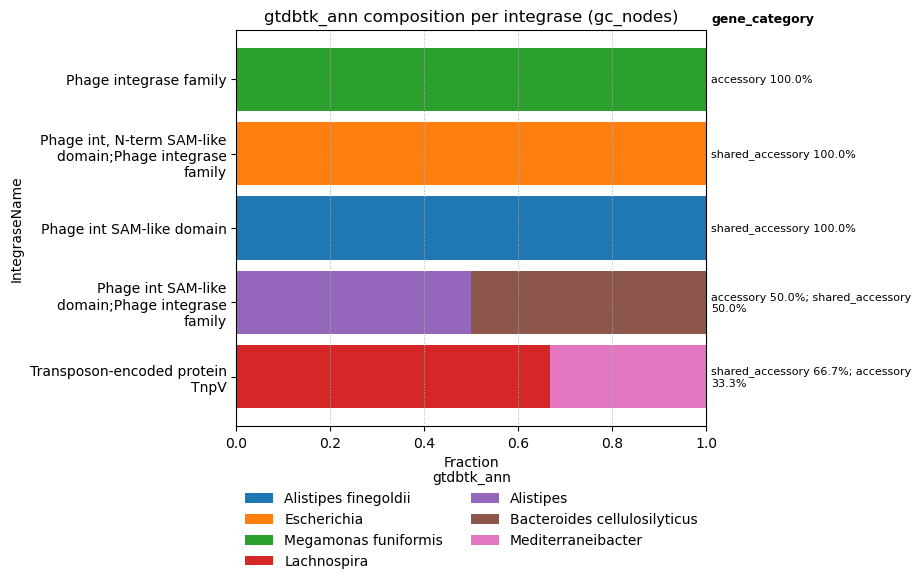

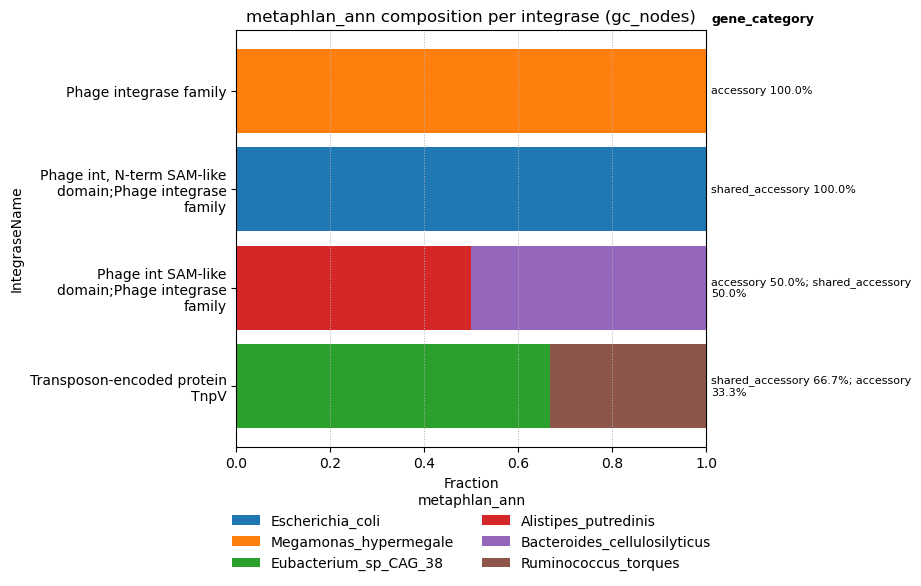

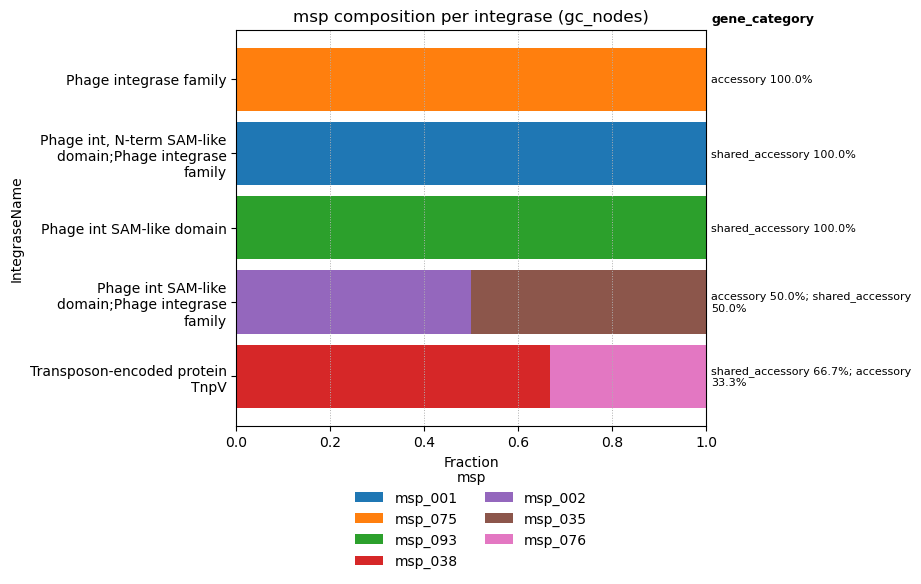

In [83]:
stacked_composition_barh(integrase_tax_df, "gtdbtk_ann", top_taxa=8, top_integrases=20, value="gc_nodes",
                         legend_where="bottom", gene_cat_top=3)

stacked_composition_barh(integrase_tax_df, "metaphlan_ann", top_taxa=8, top_integrases=20, value="gc_nodes",
                         legend_where="bottom", gene_cat_top=3)

stacked_composition_barh(integrase_tax_df, "msp", top_taxa=8, top_integrases=20, value="gc_nodes",
                         legend_where="bottom", gene_cat_top=3)

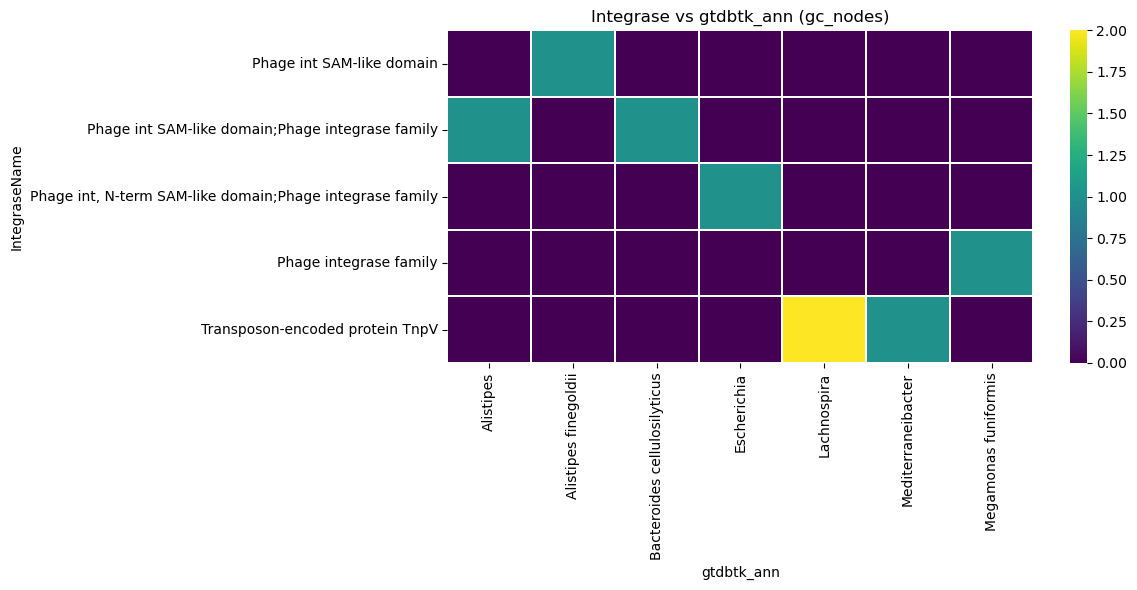

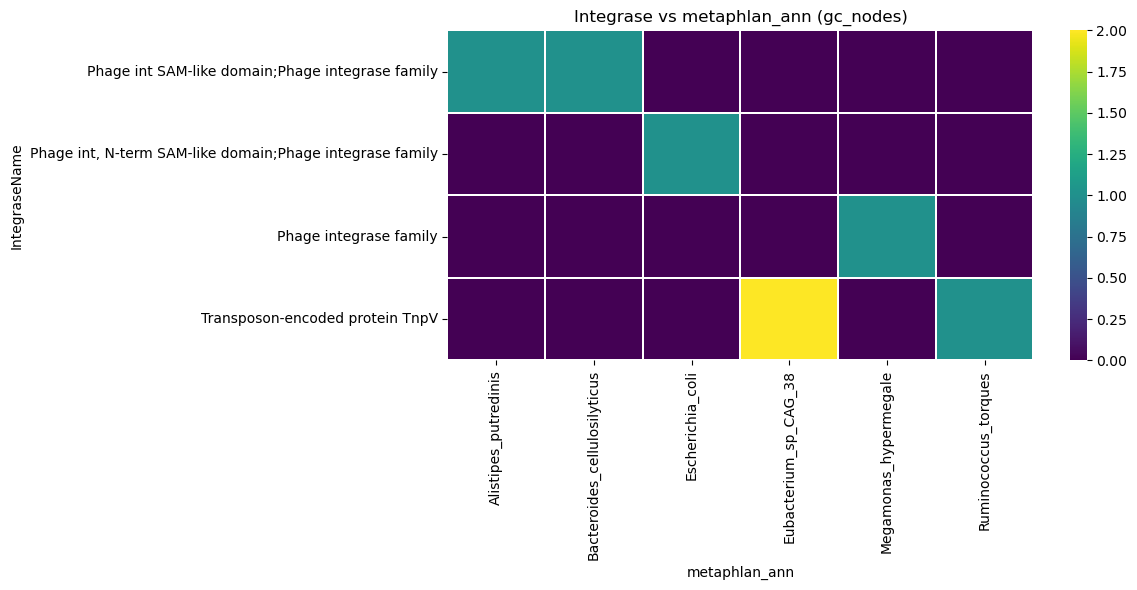

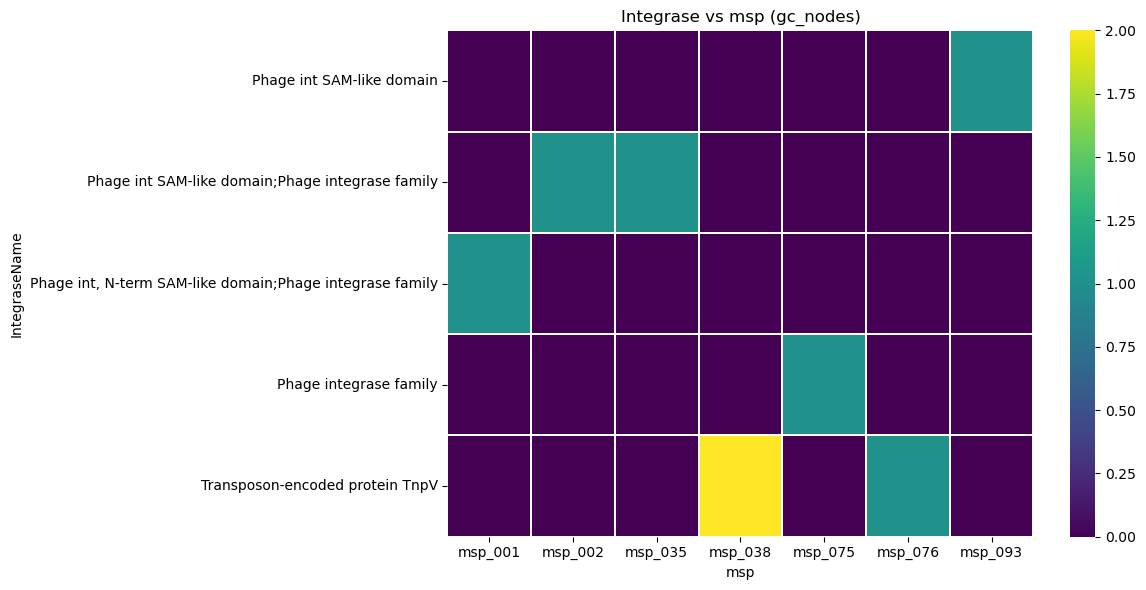

In [84]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_integrase_vs_taxa(df, tax_col, top_taxa=30, min_count=1, value="gc_nodes"):
    d = df[df[tax_col] != "Not Annotated"].copy()

    if value == "graphs":
        # count unique graphs instead of gc nodes
        tab = (d.groupby(["IntegraseName", tax_col])["Graph"]
                 .nunique()
                 .reset_index(name="count"))
    else:
        tab = (d.groupby(["IntegraseName", tax_col])["gc_id"]
                 .nunique()
                 .reset_index(name="count"))

    # keep top taxa overall
    top = (tab.groupby(tax_col)["count"].sum().sort_values(ascending=False).head(top_taxa).index)
    tab = tab[tab[tax_col].isin(top) & (tab["count"] >= min_count)]

    mat = tab.pivot(index="IntegraseName", columns=tax_col, values="count").fillna(0)

    plt.figure(figsize=(12, max(6, 0.3 * mat.shape[0])))
    sns.heatmap(mat, cmap="viridis", linewidths=0.2)
    plt.title(f"Integrase vs {tax_col} ({value})")
    plt.xlabel(tax_col)
    plt.ylabel("IntegraseName")
    plt.tight_layout()
    plt.show()

heatmap_integrase_vs_taxa(integrase_tax_df, "gtdbtk_ann", top_taxa=25, value="gc_nodes")
heatmap_integrase_vs_taxa(integrase_tax_df, "metaphlan_ann", top_taxa=25, value="gc_nodes")
# for MSP, this is Integrase vs MSP id:
heatmap_integrase_vs_taxa(integrase_tax_df, "msp", top_taxa=25, value="gc_nodes")

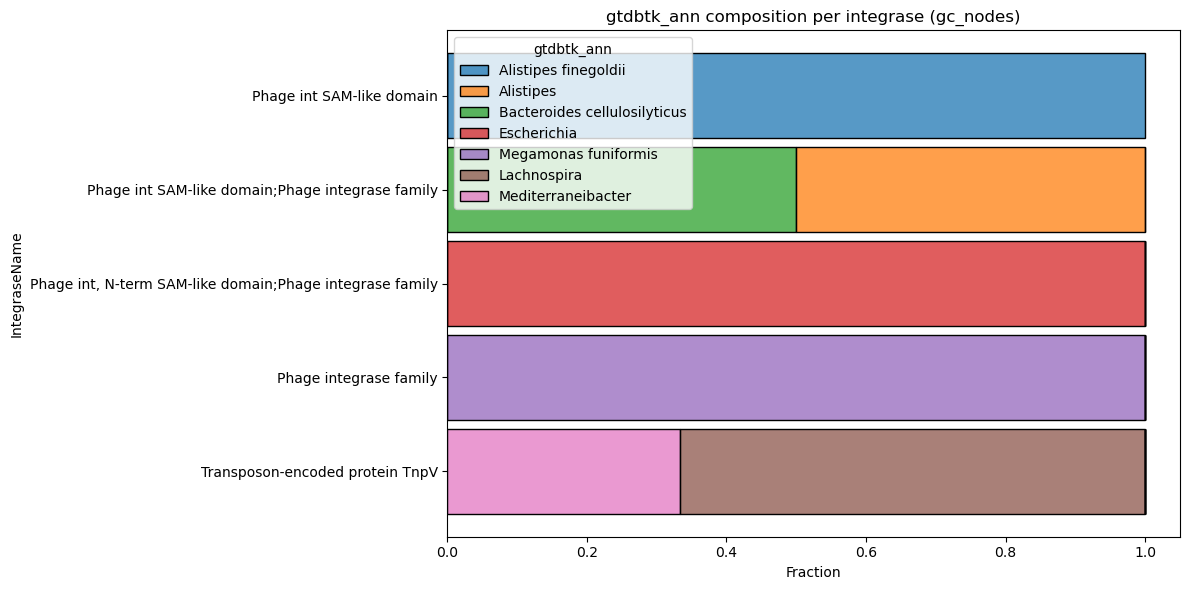

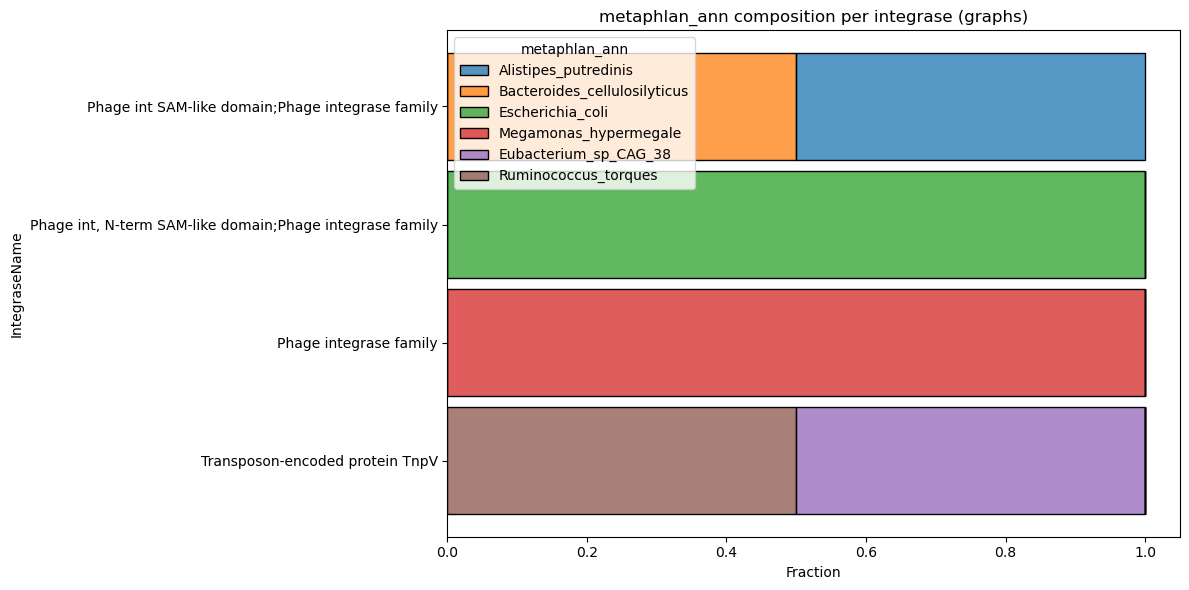

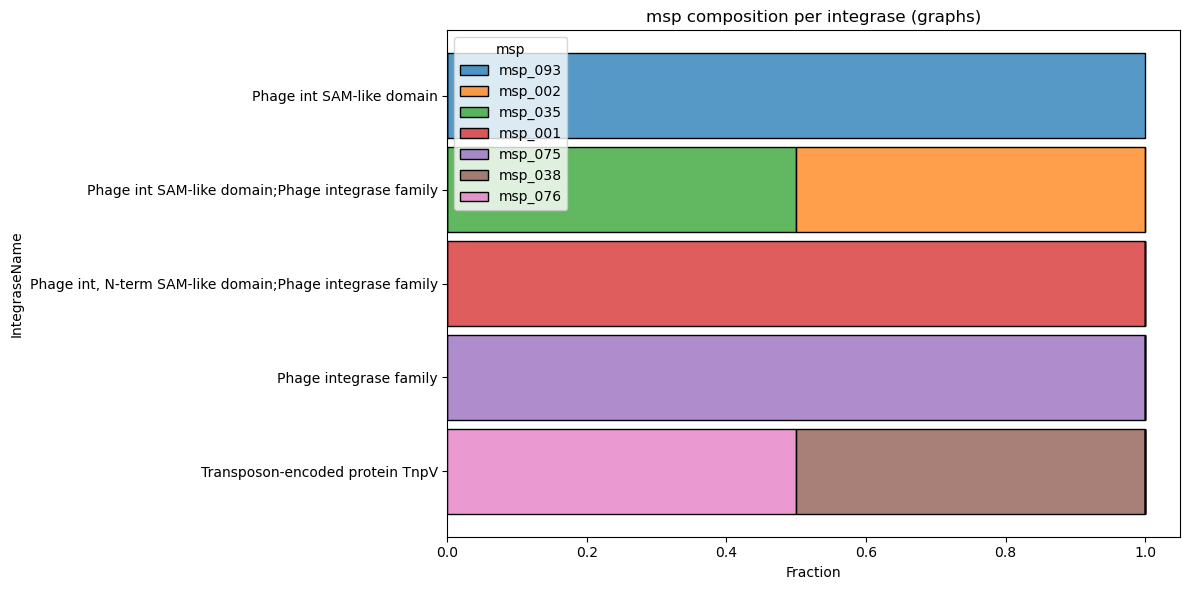

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

def stacked_composition(df, tax_col, top_taxa=10, top_integrases=25, value="gc_nodes"):
    d = df[df[tax_col] != "Not Annotated"].copy()

    if value == "graphs":
        tab = (d.groupby(["IntegraseName", tax_col])["Graph"]
                 .nunique()
                 .reset_index(name="count"))
        integ_tot = (d.groupby("IntegraseName")["Graph"].nunique().sort_values(ascending=False))
    else:
        tab = (d.groupby(["IntegraseName", tax_col])["gc_id"]
                 .nunique()
                 .reset_index(name="count"))
        integ_tot = (d.groupby("IntegraseName")["gc_id"].nunique().sort_values(ascending=False))

    keep_integrases = integ_tot.head(top_integrases).index
    tab = tab[tab["IntegraseName"].isin(keep_integrases)]

    top = (tab.groupby(tax_col)["count"].sum().sort_values(ascending=False).head(top_taxa).index)
    tab[tax_col] = tab[tax_col].where(tab[tax_col].isin(top), other="Other")

    tab = (tab.groupby(["IntegraseName", tax_col])["count"].sum().reset_index())
    tab["frac"] = tab["count"] / tab.groupby("IntegraseName")["count"].transform("sum")

    plt.figure(figsize=(12, max(6, 0.35 * len(keep_integrases))))
    sns.histplot(
        data=tab,
        y="IntegraseName",
        weights="frac",
        hue=tax_col,
        multiple="stack",
        shrink=0.9,
        legend=True
    )
    plt.xlabel("Fraction")
    plt.ylabel("IntegraseName")
    plt.title(f"{tax_col} composition per integrase ({value})")
    plt.tight_layout()
    plt.show()

stacked_composition(integrase_tax_df, "gtdbtk_ann", top_taxa=8, top_integrases=20, value="gc_nodes")
stacked_composition(integrase_tax_df, "metaphlan_ann", top_taxa=8, top_integrases=20, value="graphs")
stacked_composition(integrase_tax_df, "msp", top_taxa=8, top_integrases=20, value="graphs")

# Abundance correlation heatmaps

In [86]:
def build_mean_abundance_per_sample_df(
    graph_to_subgraph: dict,
    gc_node_map: dict,              # e.g., gc_node_to_AMR or gc_node_to_integrase
    value_col: str,                 # e.g., "MeanAbundance_AMR"
) -> pd.DataFrame:
    rows = []

    for graph_key, sg in graph_to_subgraph.items():
        try:
            graph_id = str(get_graph_id(sg))
        except Exception:
            graph_id = str(graph_key)

        gc_id_to_node = getattr(sg, "gc_id_to_node", None)
        if gc_id_to_node is None:
            raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

        matched_gc_ids = [gc_id for gc_id in gc_id_to_node.keys() if gc_id in gc_node_map]
        if not matched_gc_ids:
            continue

        sample_ids = set()
        for gc_id in matched_gc_ids:
            ann = getattr(gc_id_to_node[gc_id], "abundance_annotation", None)
            if ann is None:
                raise AttributeError(f"Node for gc_id={gc_id} in graph={graph_id} has no 'abundance_annotation'")
            sample_ids.update(ann.keys())

        for sample_id in sample_ids:
            vals = []
            for gc_id in matched_gc_ids:
                v = gc_id_to_node[gc_id].abundance_annotation.get(sample_id, 0)
                try:
                    vals.append(float(v))
                except Exception:
                    vals.append(0.0)

            rows.append(
                {
                    "graph_id": graph_id,
                    "sample_id": str(sample_id),
                    value_col: float(np.mean(vals)) if vals else np.nan,
                }
            )

    df = pd.DataFrame(rows).dropna(subset=[value_col])
    df["graph_id"] = df["graph_id"].astype(str)
    return df


integrase_sample_df = build_mean_abundance_per_sample_df(
    graph_to_subgraph=graph_to_subgraph,
    gc_node_map=gc_node_to_integrase,
    value_col="MeanAbundance_Integrase",
)

amr_sample_df = build_mean_abundance_per_sample_df(
    graph_to_subgraph=graph_to_subgraph,
    gc_node_map=gc_node_to_AMR,
    value_col="MeanAbundance_AMR",
)

In [87]:
pairwise_sample_df = (
    integrase_sample_df.rename(columns={"graph_id": "integrase_graph_id"})
    .merge(amr_sample_df.rename(columns={"graph_id": "amr_graph_id"}), on="sample_id", how="inner")
)

pairwise_sample_df = pairwise_sample_df[
    ["sample_id", "integrase_graph_id", "amr_graph_id", "MeanAbundance_Integrase", "MeanAbundance_AMR"]
]

pairwise_sample_df.head()

,sample_id,integrase_graph_id,amr_graph_id,MeanAbundance_Integrase,MeanAbundance_AMR
0,DRR171996,graph_0,graph_0,0.0,0.0
1,DRR171996,graph_0,graph_1,0.0,0.0
2,DRR171996,graph_0,graph_10,0.0,0.0
3,DRR171996,graph_0,graph_11,0.0,0.0
4,DRR171996,graph_0,graph_12,0.0,0.0


In [88]:
def p_to_stars_6bins(p: float) -> str:
    if p is None or np.isnan(p):
        return ""
    if p <= 1e-5:
        return "*****"
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return ""  # 0 stars


def pearsonr_safe(x: np.ndarray, y: np.ndarray) -> tuple[float, float, int]:
    mask = np.isfinite(x) & np.isfinite(y)
    n = int(mask.sum())
    if n < 3:
        return np.nan, np.nan, n

    xx = x[mask]
    yy = y[mask]

    # pearsonr fails on constant inputs; treat as undefined
    if np.all(xx == xx[0]) or np.all(yy == yy[0]):
        return np.nan, np.nan, n

    r, p = pearsonr(xx, yy)
    return float(r), float(p), n


def compute_cross_graph_spearman(
    integrase_sample_df: pd.DataFrame,
    amr_sample_df: pd.DataFrame,
    drop_zero_zero: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    I = integrase_sample_df.pivot(index="sample_id", columns="graph_id", values="MeanAbundance_Integrase")
    A = amr_sample_df.pivot(index="sample_id", columns="graph_id", values="MeanAbundance_AMR")

    # Align samples (inner join by sample_id)
    common_samples = I.index.intersection(A.index)
    I = I.loc[common_samples]
    A = A.loc[common_samples]

    # Rank-transform once (Spearman = Pearson on ranks)
    Ir = I.rank(axis=0, method="average", na_option="keep")
    Ar = A.rank(axis=0, method="average", na_option="keep")

    int_graphs = list(Ir.columns)
    amr_graphs = list(Ar.columns)

    rho_mat = pd.DataFrame(index=int_graphs, columns=amr_graphs, dtype=float)
    p_mat = pd.DataFrame(index=int_graphs, columns=amr_graphs, dtype=float)
    n_mat = pd.DataFrame(index=int_graphs, columns=amr_graphs, dtype=float)

    rows = []
    for ig in int_graphs:
        x_rank = Ir[ig].to_numpy(dtype=float)
        x_raw = I[ig].to_numpy(dtype=float)  # only needed if drop_zero_zero

        for ag in amr_graphs:
            y_rank = Ar[ag].to_numpy(dtype=float)
            y_raw = A[ag].to_numpy(dtype=float)

            if drop_zero_zero:
                keep = ~((x_raw == 0) & (y_raw == 0))
                xr = x_rank.copy()
                yr = y_rank.copy()
                xr[~keep] = np.nan
                yr[~keep] = np.nan
                r, p, n = pearsonr_safe(xr, yr)
            else:
                r, p, n = pearsonr_safe(x_rank, y_rank)

            rho_mat.loc[ig, ag] = r
            p_mat.loc[ig, ag] = p
            n_mat.loc[ig, ag] = n

            rows.append(
                {
                    "integrase_graph_id": ig,
                    "amr_graph_id": ag,
                    "spearman_r": r,
                    "spearman_p": p,
                    "n_samples": n,
                }
            )

    long_df = pd.DataFrame(rows)
    return long_df, rho_mat, p_mat, n_mat


cross_long_df, rho_mat, p_mat, n_mat = compute_cross_graph_spearman(
    integrase_sample_df=integrase_sample_df,
    amr_sample_df=amr_sample_df,
    drop_zero_zero=False,  # set True if you want to drop (0,0) pairs per cell
)

cross_long_df.head()

,integrase_graph_id,amr_graph_id,spearman_r,spearman_p,n_samples
0,graph_0,graph_0,0.735108,1.463032e-105,615
1,graph_0,graph_1,-0.041976,2.986653e-01,615
2,graph_0,graph_10,0.098053,1.499270e-02,615
3,graph_0,graph_11,-0.019931,6.217934e-01,615
4,graph_0,graph_12,0.055987,1.655337e-01,615


/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/1526990439.py:57: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  rho = rho.groupby(axis=1, level=0).mean()
/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/1526990439.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  p = p.groupby(axis=1, level=0).mean()


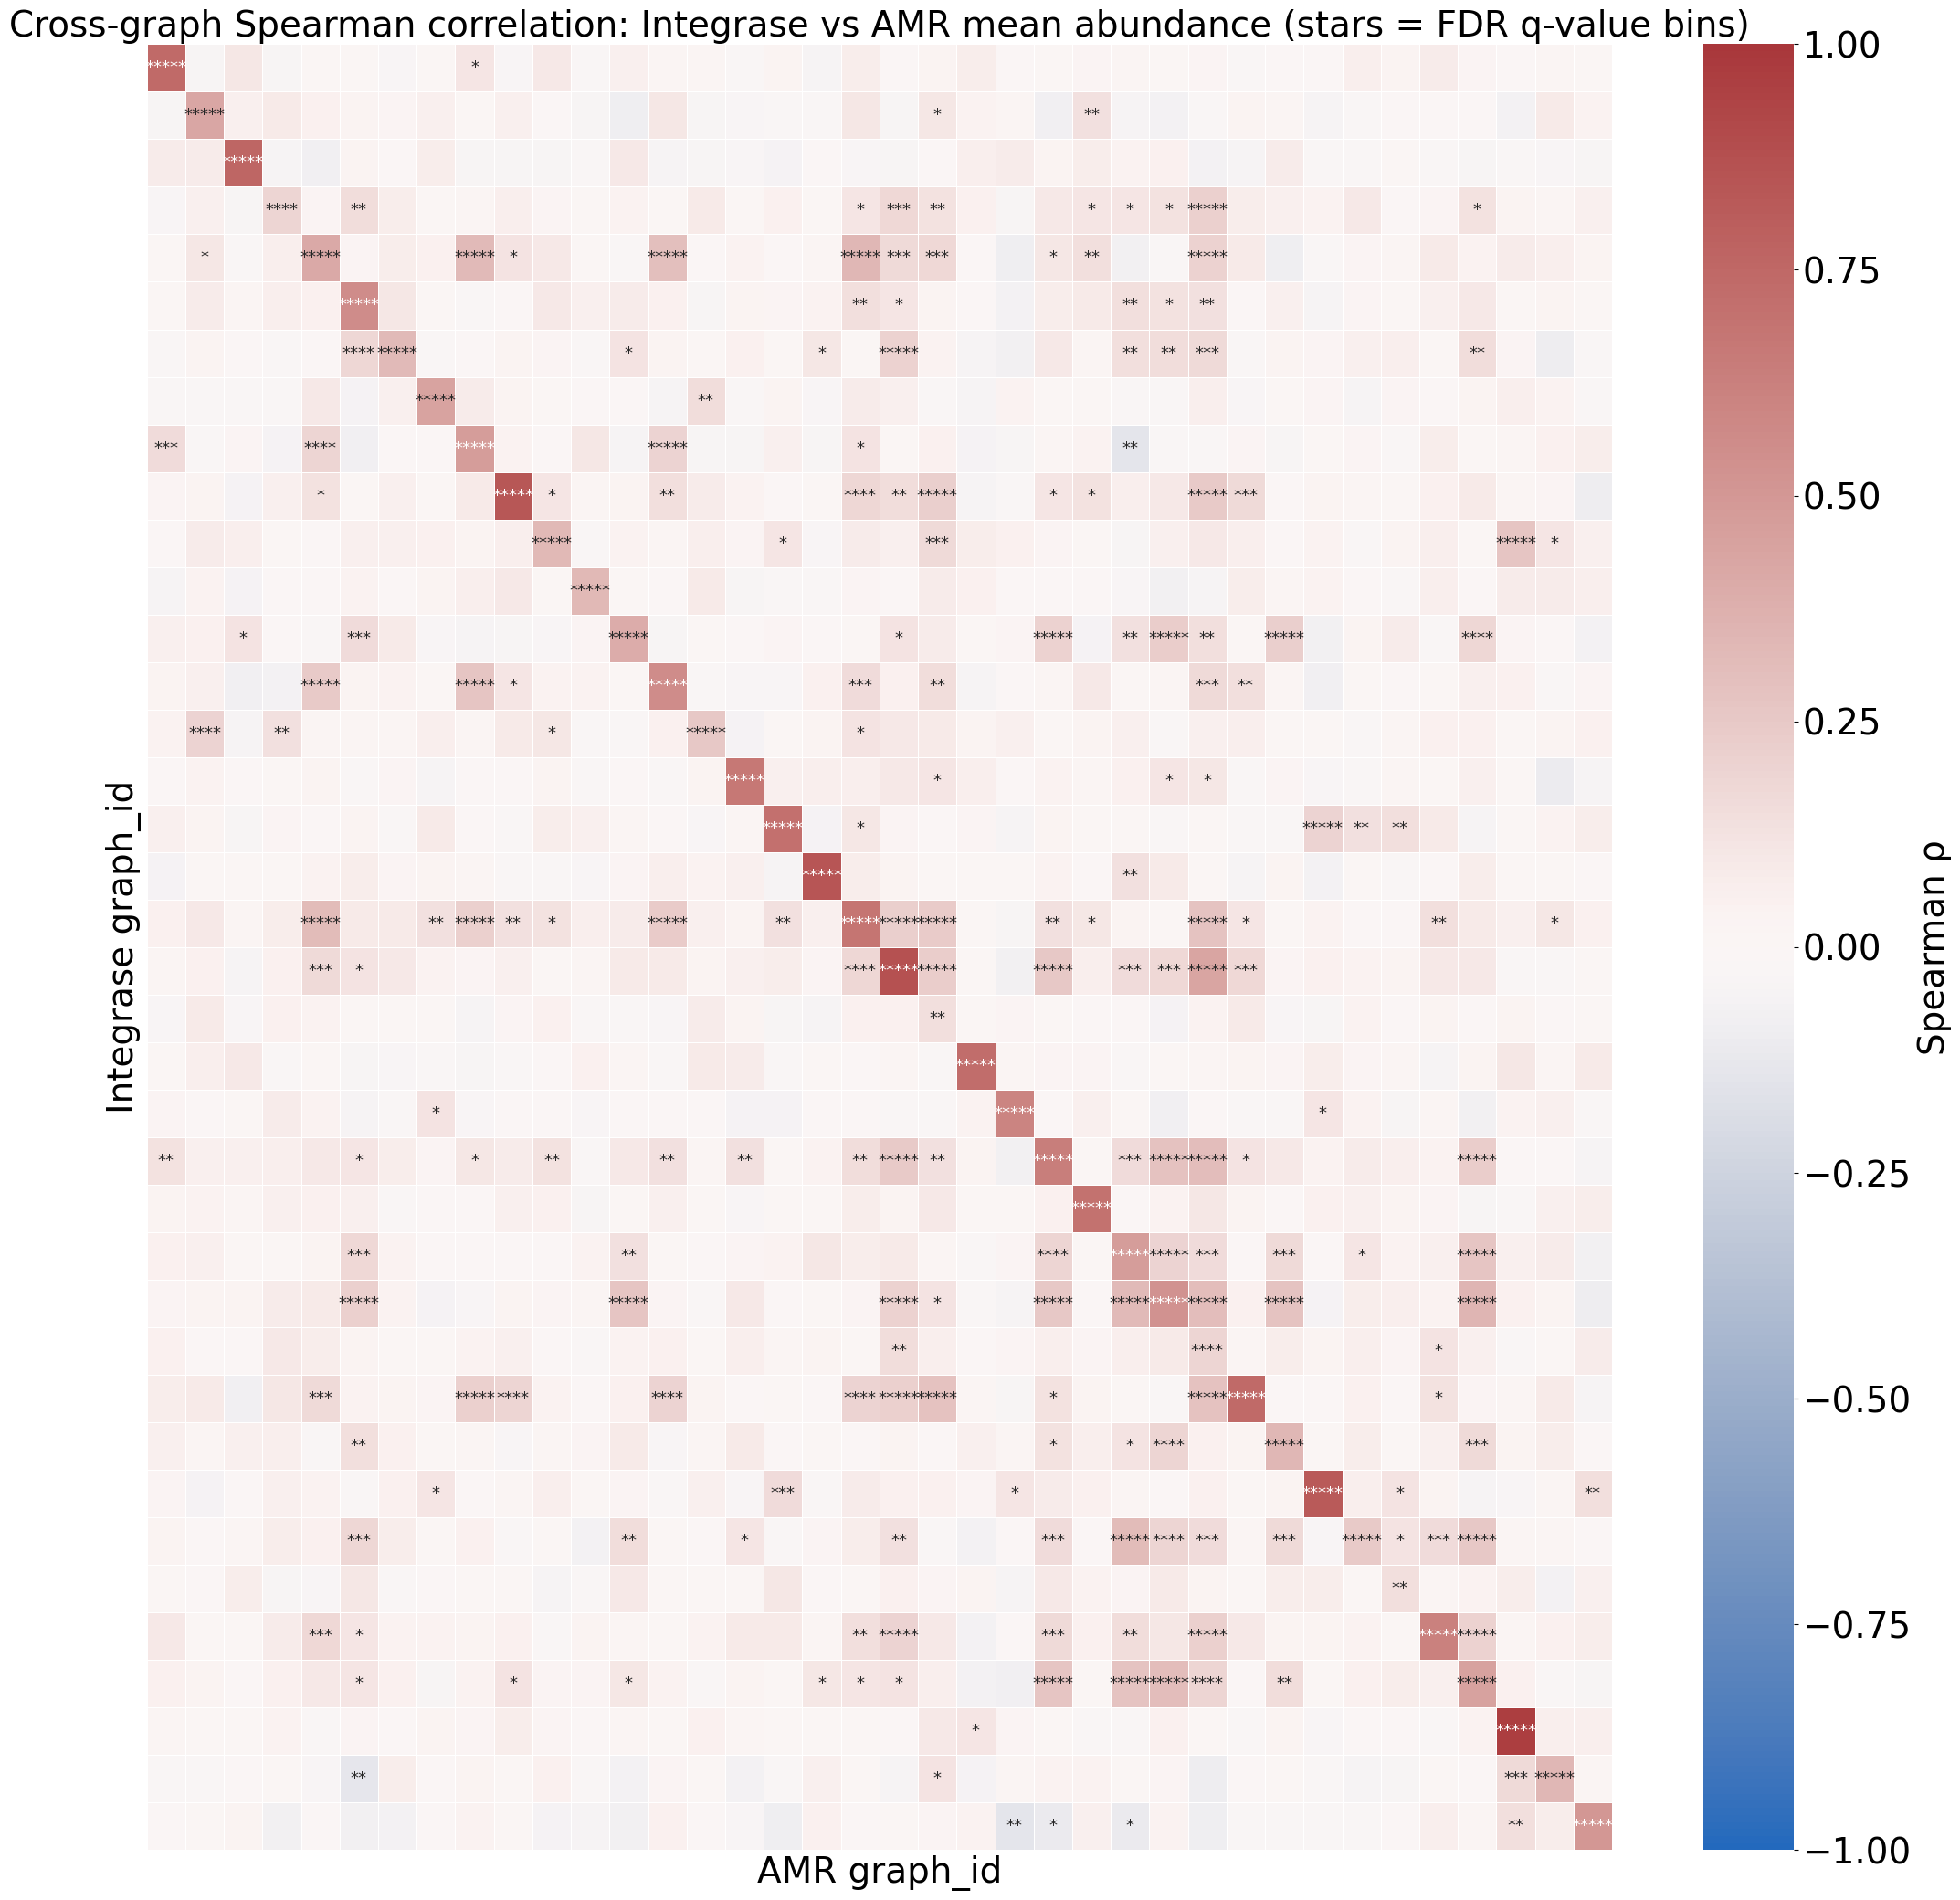

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/1526990439.py:57: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  rho = rho.groupby(axis=1, level=0).mean()
/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_72788/1526990439.py:59: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  p = p.groupby(axis=1, level=0).mean()


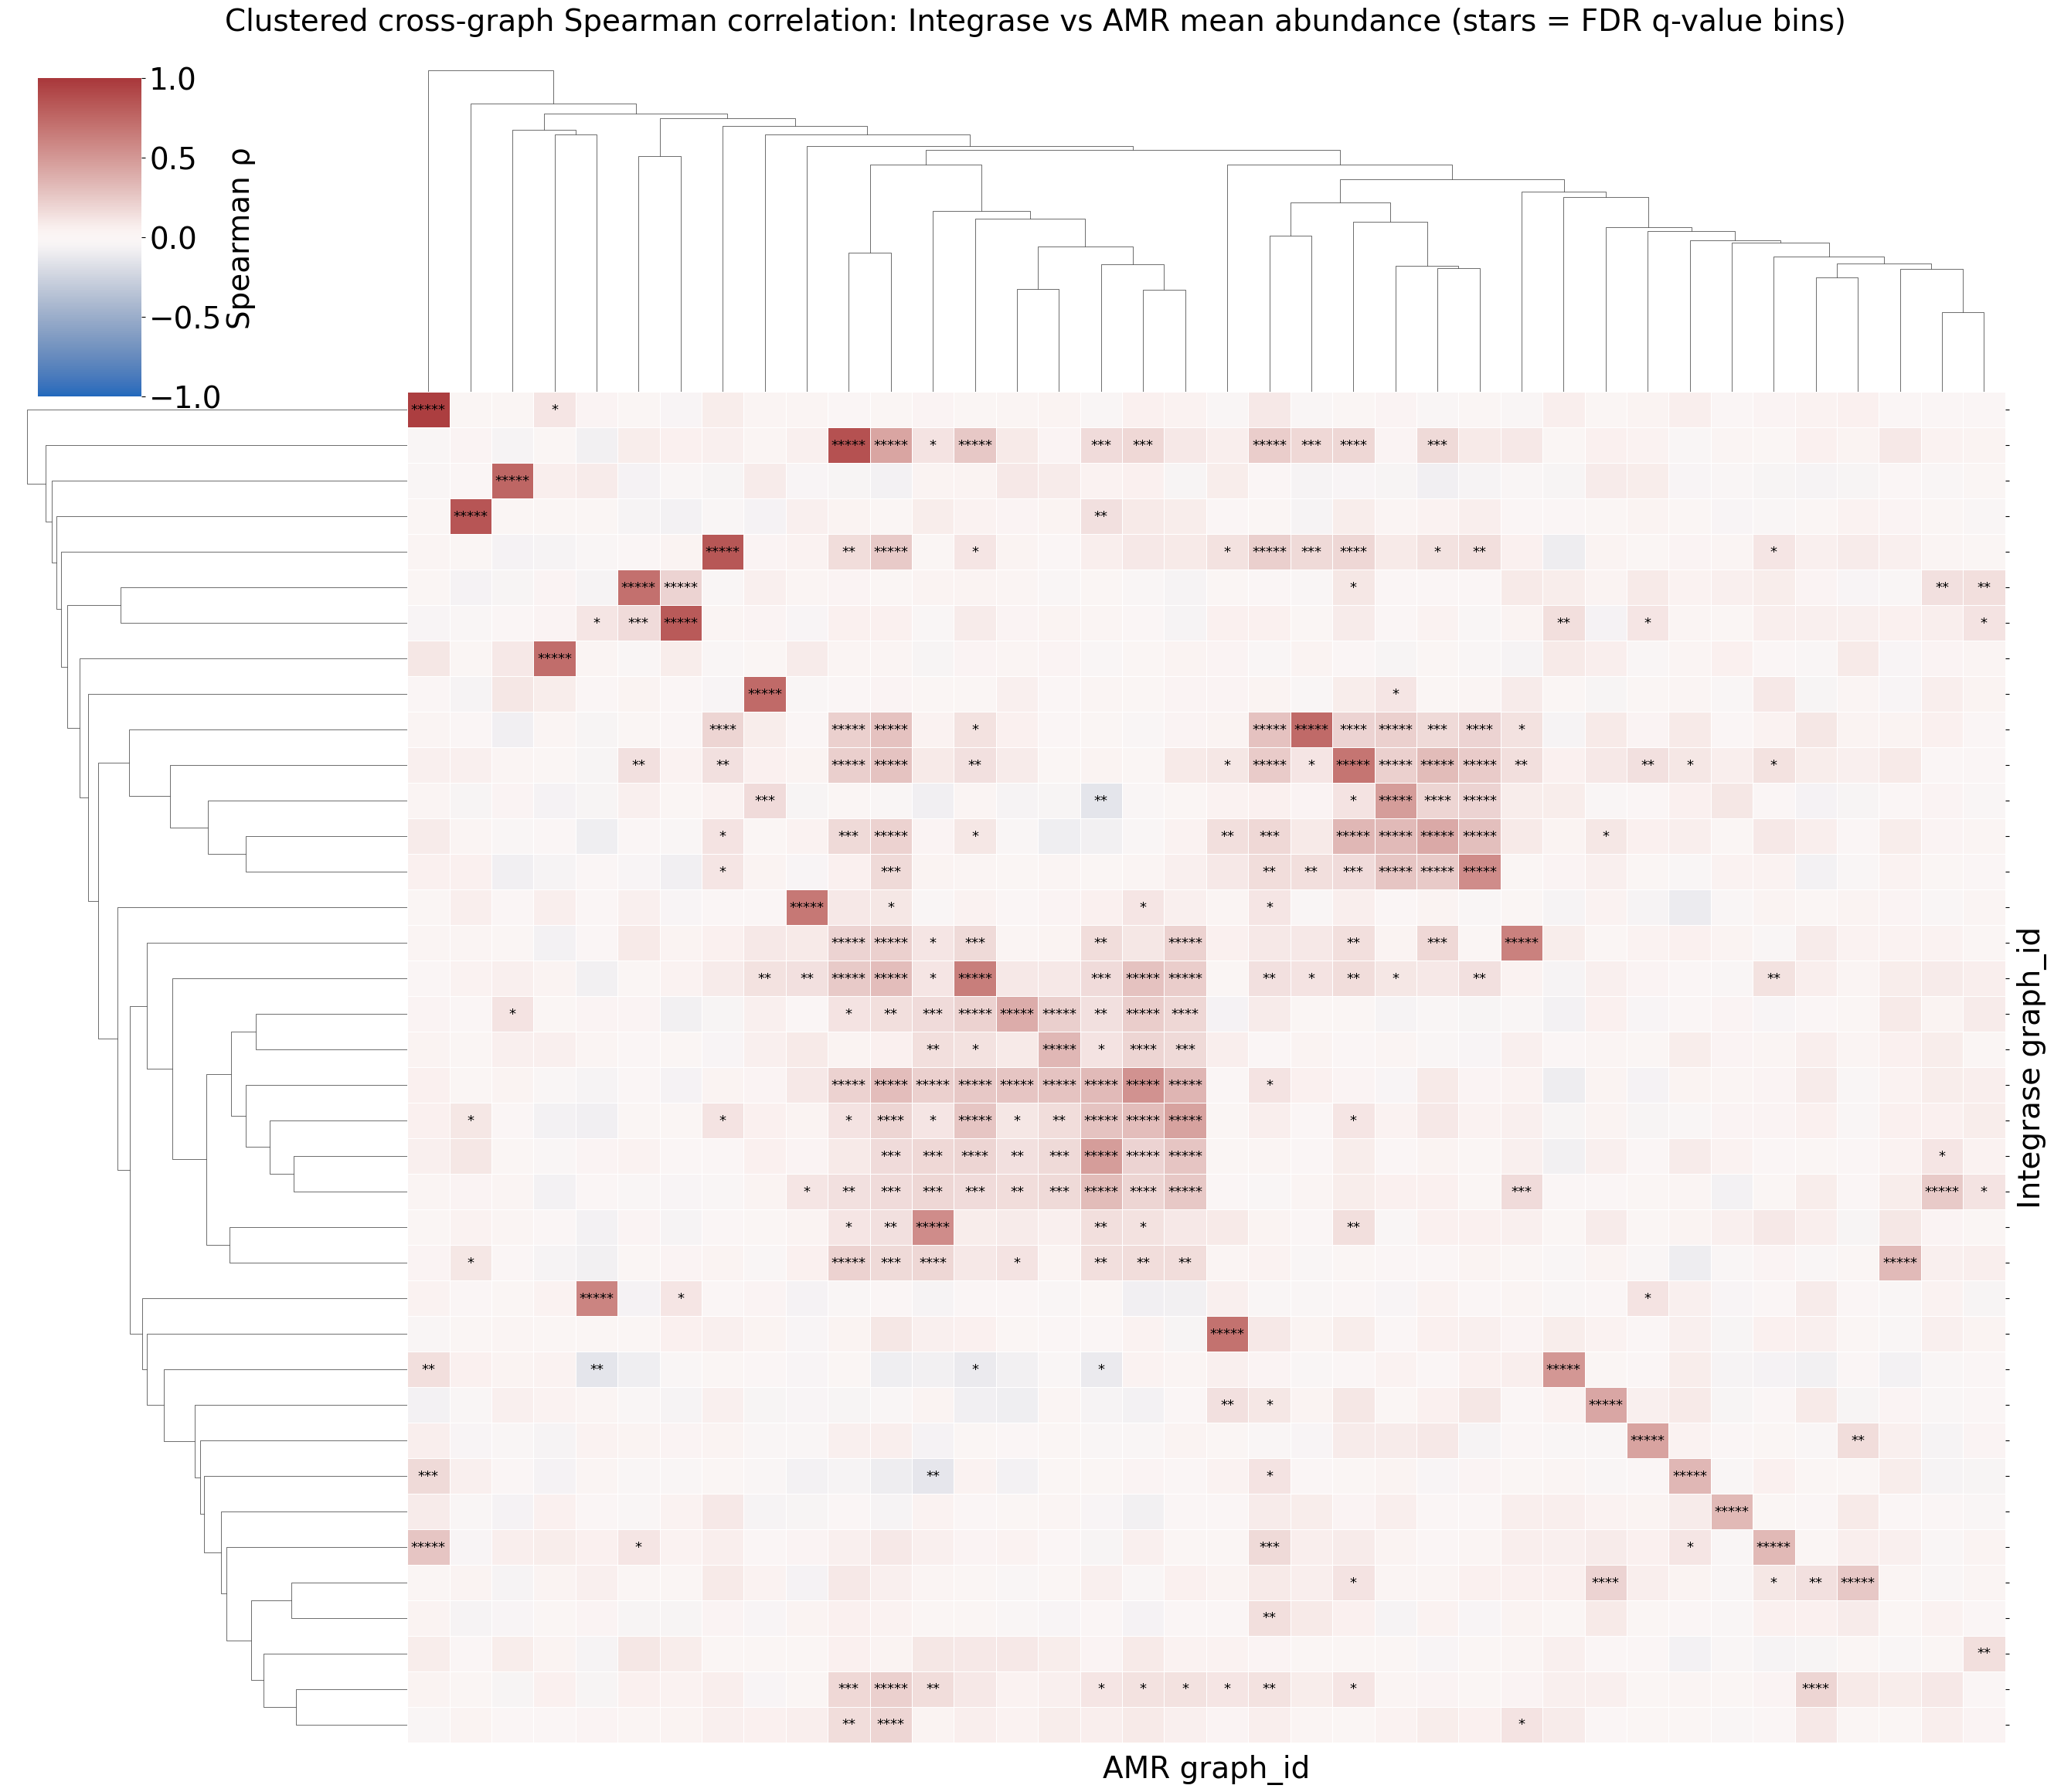

In [96]:
def _normalize_graph_id(g: str) -> str:
    # turns "graph_2" -> "graph_02", keeps "graph_12" -> "graph_12"
    s = str(g)
    m = re.search(r"(graph_)(\d+)$", s)
    if not m:
        return s
    prefix, num = m.group(1), int(m.group(2))
    return f"{prefix}{num:02d}"


def _sort_graph_ids(ids) -> list[str]:
    # numeric sort by suffix if present, otherwise lexicographic
    norm = [_normalize_graph_id(x) for x in ids]
    def key_fn(s: str):
        m = re.search(r"(\d+)$", s)
        return (0, int(m.group(1))) if m else (1, s)
    return sorted(set(norm), key=key_fn)


def fdr_bh_adjust(pvals_1d: np.ndarray) -> np.ndarray:
    # Benjamini-Hochberg FDR q-values (no statsmodels needed)
    p = np.asarray(pvals_1d, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    pv = p[ok]
    if pv.size == 0:
        return q

    order = np.argsort(pv)
    pv_sorted = pv[order]
    m = pv_sorted.size

    ranks = np.arange(1, m + 1, dtype=float)
    q_sorted = pv_sorted * m / ranks
    # enforce monotonicity
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(pv_sorted)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q


def make_annot_matrix(rho_mat: pd.DataFrame, p_mat: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    # 1) normalize + sort axes (graph_2 -> graph_02)
    rho = rho_mat.copy()
    p = p_mat.copy()

    rho.index = [_normalize_graph_id(x) for x in rho.index]
    rho.columns = [_normalize_graph_id(x) for x in rho.columns]
    p.index = [_normalize_graph_id(x) for x in p.index]
    p.columns = [_normalize_graph_id(x) for x in p.columns]

    # align after normalization (in case collisions happen)
    rho = rho.groupby(level=0).mean()
    rho = rho.groupby(axis=1, level=0).mean()
    p = p.groupby(level=0).mean()
    p = p.groupby(axis=1, level=0).mean()

    row_order = _sort_graph_ids(rho.index)
    col_order = _sort_graph_ids(rho.columns)
    rho = rho.reindex(index=row_order, columns=col_order)
    p = p.reindex(index=row_order, columns=col_order)

    # 2) FDR correction across all cells (BH)
    pvals = p.to_numpy(dtype=float).ravel()
    qvals = fdr_bh_adjust(pvals).reshape(p.shape)
    q = pd.DataFrame(qvals, index=p.index, columns=p.columns)

    # 3) build annotation with stars from q-values (FDR)
    annot = np.empty(rho.shape, dtype=object)
    for i in range(rho.shape[0]):
        for j in range(rho.shape[1]):
            r = rho.iat[i, j]
            qv = q.iat[i, j]
            if not np.isfinite(r):
                annot[i, j] = ""
            else:
                stars = p_to_stars_6bins(qv)  # stars reflect FDR-adjusted q
                annot[i, j] = stars if stars else ""

    return annot, rho


# --- clustered heatmap with dendrograms + your (rho + stars) annotations ---

TITLE_FS = 28
AXISLABEL_FS = 28
CBARLABEL_FS = 28
CBARTICKS_FS = 28
ANNOT_FS = 13

# --- 1) WITHOUT clustering (your original heatmap) ---
annot, rho_sorted = make_annot_matrix(rho_mat, p_mat)

n_rows, n_cols = rho_sorted.shape
cell_w, cell_h = 0.55, 0.55
fig_w = max(14, n_cols * cell_w)
fig_h = max(10, n_rows * cell_h)

plt.figure(figsize=(fig_w, fig_h))
ax = sns.heatmap(
    rho_sorted.astype(float),
    vmin=-1, vmax=1,
    cmap="vlag",
    annot=annot,
    fmt="",
    annot_kws={"fontsize": ANNOT_FS},
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Spearman ρ"},
    xticklabels=False,
    yticklabels=False,
)
ax.set_xlabel("AMR graph_id", fontsize=AXISLABEL_FS)
ax.set_ylabel("Integrase graph_id", fontsize=AXISLABEL_FS)
ax.set_title(
    "Cross-graph Spearman correlation: Integrase vs AMR mean abundance (stars = FDR q-value bins)",
    fontsize=TITLE_FS
)

ax.tick_params(axis="both", which="both", bottom=False, left=False)

cbar = ax.collections[0].colorbar
cbar.set_label("Spearman ρ", fontsize=CBARLABEL_FS)
cbar.ax.tick_params(labelsize=CBARTICKS_FS)

plt.tight_layout()
plt.show()


# --- 2) WITH clustering (clustermap + same annotations) ---
annot, rho_sorted = make_annot_matrix(rho_mat, p_mat)
rho_float = rho_sorted.astype(float)

nan_mask = ~np.isfinite(rho_float.to_numpy())
mask_df = pd.DataFrame(nan_mask, index=rho_float.index, columns=rho_float.columns)

# clustermap cannot cluster NaNs; fill for clustering, mask for display
rho_fill = rho_float.mask(mask_df, 0.0)

n_rows, n_cols = rho_sorted.shape
cell_w, cell_h = 0.55, 0.55
fig_w = max(16, n_cols * cell_w + 6)
fig_h = max(12, n_rows * cell_h + 2)

g = sns.clustermap(
    rho_fill,
    vmin=-1, vmax=1,
    cmap="vlag",
    linewidths=0.7,
    linecolor="white",
    mask=mask_df,
    figsize=(fig_w, fig_h),
    method="average",
    metric="euclidean",
    cbar_kws={"label": "Spearman ρ"},

)

g.ax_heatmap.set_xlabel("AMR graph_id", fontsize=AXISLABEL_FS)
g.ax_heatmap.set_ylabel("Integrase graph_id", fontsize=AXISLABEL_FS)
g.fig.suptitle(
    "Clustered cross-graph Spearman correlation: Integrase vs AMR mean abundance (stars = FDR q-value bins)",
    y=1.02,
    fontsize=TITLE_FS
)

g.cax.set_ylabel("Spearman ρ", fontsize=CBARLABEL_FS)
g.cax.tick_params(labelsize=CBARTICKS_FS)

# reorder annotations to match clustering
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
annot_re = annot[np.ix_(row_order, col_order)]
mask_re = nan_mask[np.ix_(row_order, col_order)]

# draw annotations manually
ax = g.ax_heatmap
for i in range(annot_re.shape[0]):
    for j in range(annot_re.shape[1]):
        if mask_re[i, j]:
            continue
        txt = annot_re[i, j]
        if txt:
            ax.text(j + 0.5, i + 0.5, txt, ha="center", va="center", fontsize=ANNOT_FS)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis="both", which="both", bottom=False, left=False)

g.ax_row_dendrogram.set_xticks([])
g.ax_row_dendrogram.set_yticks([])
g.ax_col_dendrogram.set_xticks([])
g.ax_col_dendrogram.set_yticks([])

plt.show()

In [90]:
print("graph_33 in integrase_sample_df:", (integrase_sample_df["graph_id"].astype(str) == "graph_33").any() or
      (integrase_sample_df["graph_id"].astype(str) == "graph_33").any())

print("integrase graphs:", sorted({_normalize_graph_id(x) for x in integrase_sample_df["graph_id"].astype(str).unique()}))
print("amr graphs:",       sorted({_normalize_graph_id(x) for x in amr_sample_df["graph_id"].astype(str).unique()}))

graph_33 in integrase_sample_df: True
integrase graphs: ['graph_00', 'graph_01', 'graph_02', 'graph_03', 'graph_04', 'graph_05', 'graph_06', 'graph_07', 'graph_08', 'graph_09', 'graph_10', 'graph_11', 'graph_12', 'graph_13', 'graph_14', 'graph_15', 'graph_16', 'graph_17', 'graph_18', 'graph_19', 'graph_20', 'graph_21', 'graph_22', 'graph_23', 'graph_24', 'graph_25', 'graph_26', 'graph_27', 'graph_28', 'graph_29', 'graph_30', 'graph_31', 'graph_32', 'graph_33', 'graph_34', 'graph_35', 'graph_36', 'graph_37']
amr graphs: ['graph_00', 'graph_01', 'graph_02', 'graph_03', 'graph_04', 'graph_05', 'graph_06', 'graph_07', 'graph_08', 'graph_09', 'graph_10', 'graph_11', 'graph_12', 'graph_13', 'graph_14', 'graph_15', 'graph_16', 'graph_17', 'graph_18', 'graph_19', 'graph_20', 'graph_21', 'graph_22', 'graph_23', 'graph_24', 'graph_25', 'graph_26', 'graph_27', 'graph_28', 'graph_29', 'graph_30', 'graph_31', 'graph_32', 'graph_33', 'graph_34', 'graph_35', 'graph_36', 'graph_37']


In [91]:
graph_33 = graph_to_subgraph['graph_33']
for gc in graph_33.gc_id_to_node.values():
    if gc.domain_annotation:
        print(f"gc_id: {gc.gc_id}, domains: {gc.domain_annotation['functional_group']}")

gc_id: cohort_merged__DRR127476__k141_28043::2::377::565::+, domains: PF14202
gc_id: cohort_merged__DRR127478__k141_43333::2::338::526::-, domains: PF14202
gc_id: cohort_merged__DRR127485__k141_293471::1::185::1450::+, domains: PF01076
gc_id: cohort_merged__DRR171465__k141_92682::3::1052::2077::+, domains: PF13481
gc_id: cohort_merged__DRR127476__k141_92433::2::522::1145::-, domains: PF00302
gc_id: cohort_merged__DRR127476__k141_92433::3::1327::1584::-, domains: PF14198
gc_id: cohort_merged__DRR127476__k141_92433::4::1623::3746::-, domains: PF00239:::PF07508:::PF13408:::PF14287
gc_id: cohort_merged__DRR171485__k141_110834::15::19194::20492::+, domains: PF01076
gc_id: cohort_merged__DRR171697__k141_143124::4::2347::4236::-, domains: PF00239:::PF07508:::PF13408:::PF14287
gc_id: cohort_merged__DRR127519__k141_68232::2::1110::2132::+, domains: PF13481
gc_id: cohort_merged__DRR127646__k141_60604::2::631::873::+, domains: PF14198
gc_id: cohort_merged__DRR171483__k141_40180::3::2255::2626::-,